        Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                0.0     1.0       1.0        1.0  24.0     0.0     0.0   
...              ...     ...       ...        ...   ...     ...     ...   
253675           0.0     1.0       1.0        1.0  45.0     0.0     0.0   
253676           2.0     1.0       1.0        1.0  18.0     0.0     0.0   
253677           0.0     0.0       0.0        1.0  28.0     0.0     0.0   
253678           0.0     1.0       0.0        1.0  23.0     0.0     0.0   
253679           2.0     1.0       1.0        1.0  25.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                        

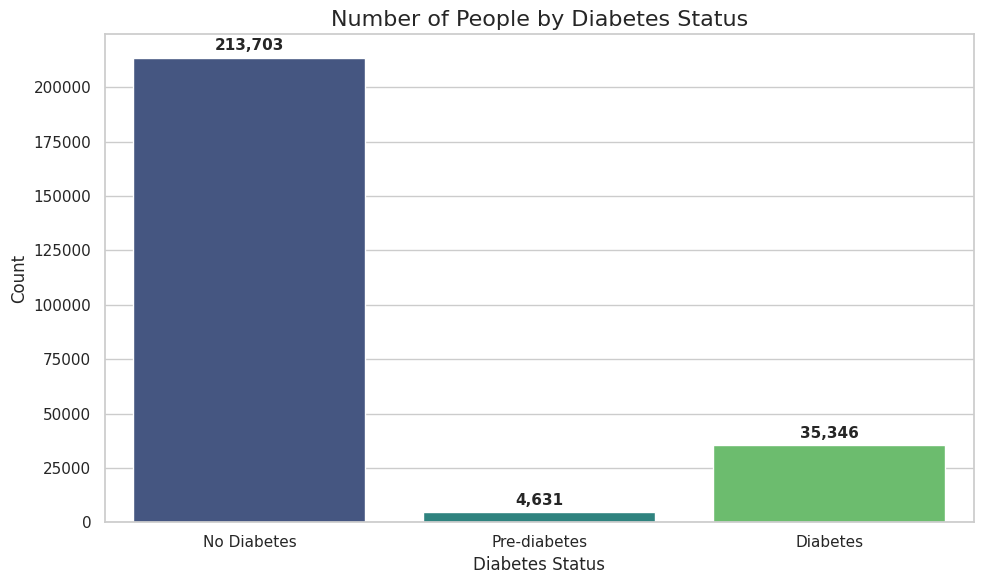

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
###########################what Data Contain #################################################
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
print(df)
diabetes_map = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}
df['Diabetes_Status'] = df['Diabetes_012'].map(diabetes_map)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,  # Assign x to hue
    palette='viridis',
    legend=False              # Hide the extra legend box
)

# Add labels and title
plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add the count numbers on top of each bar for better readability
for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_bar_chart.png')
plt.show()

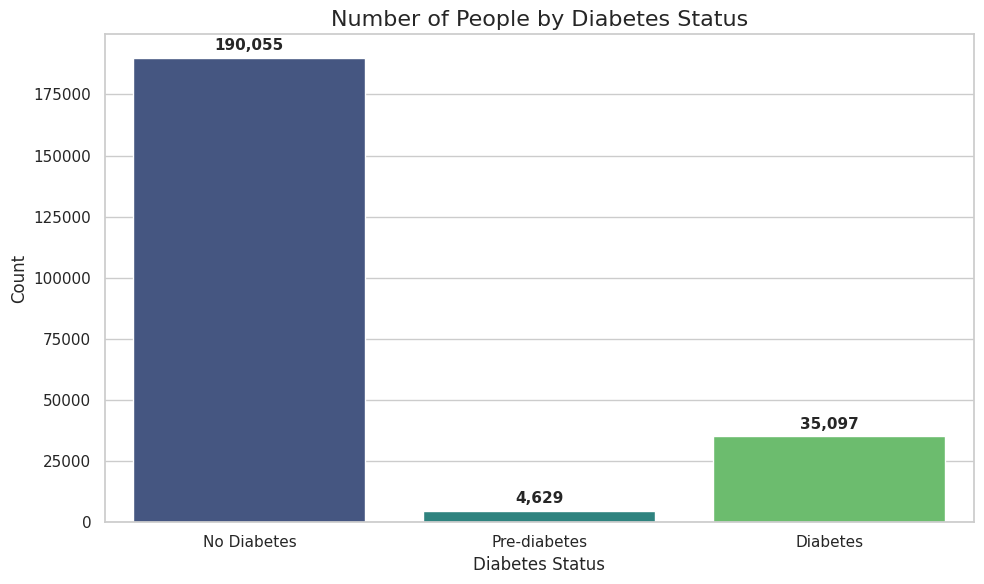

In [150]:
#cleaning Data

df.dropna(inplace= True)
df.drop_duplicates(inplace = True)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
## Data does not contain empty cell
##############################plot after remove duplicates####################################
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_after_re_dublicates.png')
plt.show()

In [151]:
x = df.drop(columns=['Diabetes_012','Diabetes_Status'])
y = df['Diabetes_012']
df=df.drop(columns=['Diabetes_Status'])
X_train_val, X_test, y_train_val, y_test = train_test_split(
    x, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # Fixed seed for reproducibility
    stratify=y         # Maintain class proportions
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,     # 12.5% of the 80% is 10% of the original
    random_state=42,
    stratify=y_train_val
)

def print_distribution(y_set, name):
    counts = y_set.value_counts().sort_index()
    percentages = y_set.value_counts(normalize=True).sort_index() * 100
    labels = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}

    print(f"--- {name} Set ---")
    for val in [0.0, 1.0, 2.0]:
        print(f"{labels[val]}: {int(counts[val])} samples ({percentages[val]:.2f}%)")
    print("-" * 30)

print_distribution(y_train, "Training (70%)")
print_distribution(y_val, "Validation (10%)")
print_distribution(y_test, "Testing (20%)")


--- Training (70%) Set ---
No Diabetes: 133038 samples (82.71%)
Pre-diabetes: 3240 samples (2.01%)
Diabetes: 24568 samples (15.27%)
------------------------------
--- Validation (10%) Set ---
No Diabetes: 19005 samples (82.71%)
Pre-diabetes: 463 samples (2.01%)
Diabetes: 3510 samples (15.28%)
------------------------------
--- Testing (20%) Set ---
No Diabetes: 38012 samples (82.71%)
Pre-diabetes: 926 samples (2.01%)
Diabetes: 7019 samples (15.27%)
------------------------------


In [152]:
### scaling the data
scaler = StandardScaler()

features_to_scale = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])
print(X_train)
print(X_val)

        HighBP  HighChol  CholCheck       BMI  Smoker  Stroke  \
107646     0.0       1.0        1.0 -0.837749     0.0     0.0   
183234     1.0       1.0        1.0  0.779355     1.0     0.0   
133308     1.0       1.0        1.0  1.367392     0.0     0.0   
116763     1.0       1.0        1.0 -0.396720     1.0     0.0   
98863      0.0       0.0        1.0  1.220383     1.0     0.0   
...        ...       ...        ...       ...     ...     ...   
29652      0.0       0.0        1.0  1.073373     1.0     0.0   
7644       0.0       1.0        1.0 -0.543730     0.0     0.0   
191656     0.0       1.0        1.0 -0.249711     1.0     0.0   
242217     1.0       1.0        1.0 -0.837749     0.0     0.0   
196847     0.0       0.0        1.0 -0.837749     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  \
107646                   0.0           1.0     1.0      1.0  ...   
183234                   0.0           1.0     1.0      1.0  ...   
133308         

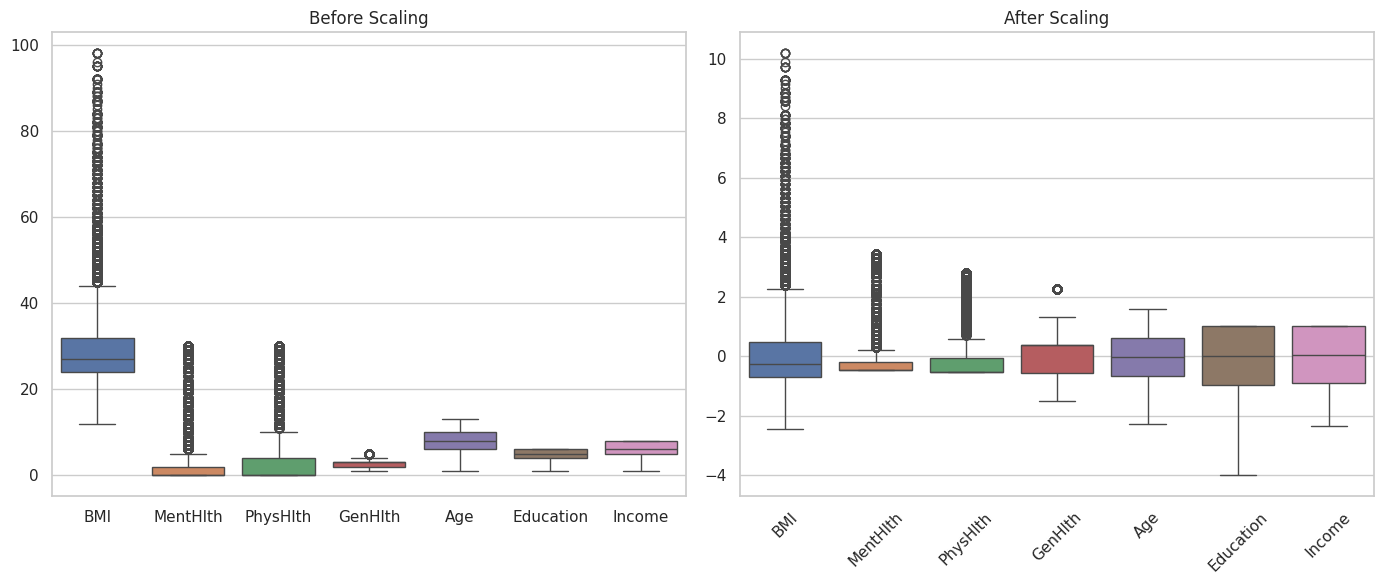

In [153]:
### plot before and after scaling ###########
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(data=df[features_to_scale], ax=ax[0])
ax[0].set_title("Before Scaling")

sns.boxplot(data=X_train[features_to_scale], ax=ax[1])
ax[1].set_title("After Scaling")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

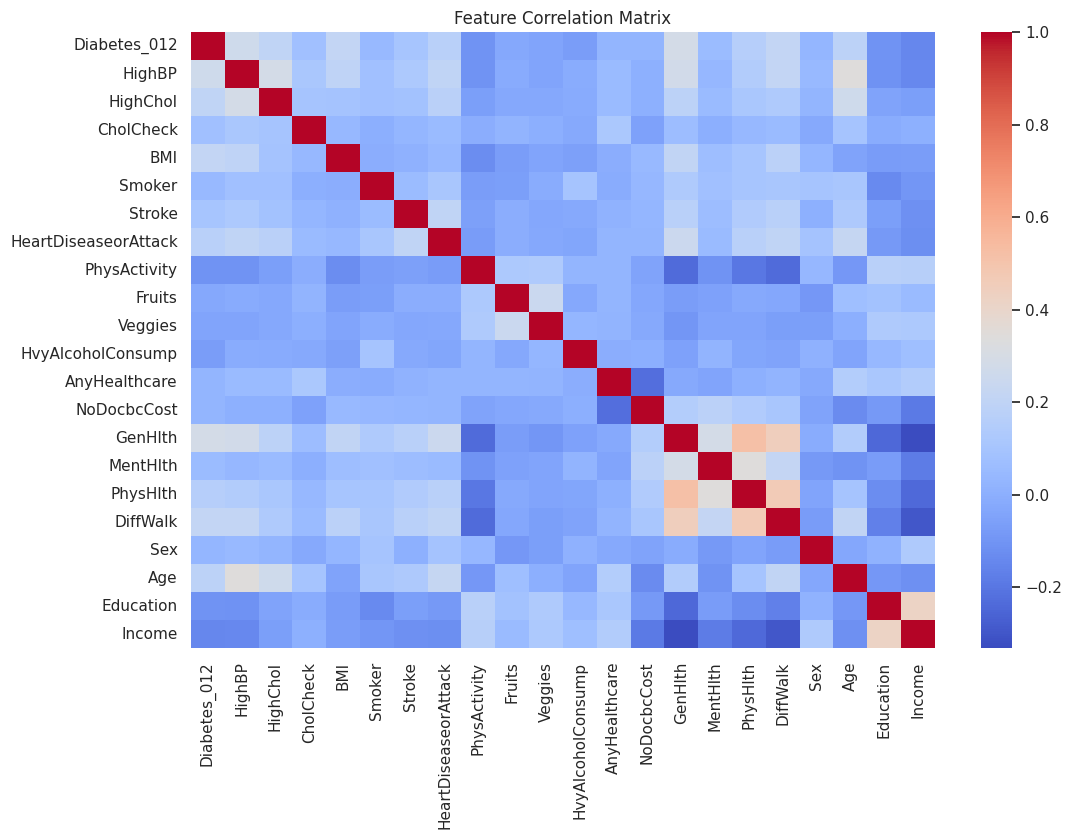

Diabetes_012            1.000000
GenHlth                 0.284881
HighBP                  0.261976
BMI                     0.212027
DiffWalk                0.210638
HighChol                0.203327
Age                     0.184642
HeartDiseaseorAttack    0.170816
PhysHlth                0.160485
Stroke                  0.100276
CholCheck               0.075701
MentHlth                0.057698
Smoker                  0.046774
Sex                     0.032243
AnyHealthcare           0.024911
NoDocbcCost             0.023568
Fruits                 -0.025462
Veggies                -0.043446
HvyAlcoholConsump      -0.067164
PhysActivity           -0.103408
Education              -0.107742
Income                 -0.147102
Name: Diabetes_012, dtype: float64


In [154]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

correlation_matrix = df.corr()
diabetes_correlation = correlation_matrix["Diabetes_012"]
sorted_correlation = diabetes_correlation.sort_values(ascending=False)
print(sorted_correlation)


In [155]:
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(x, y)
scores = selector.scores_

feature_score_pairs = list(zip(x.columns, scores))


feature_score_pairs.sort(key=lambda x: x[1], reverse=True)


print(f"{'Feature':<22} | {'Chi-Squared Score'}")
print("-" * 40)
for feature, score in feature_score_pairs:
    print(f"{feature:<22} | {score:.4f}")

Feature                | Chi-Squared Score
----------------------------------------
PhysHlth               | 103705.8134
BMI                    | 16667.0062
MentHlth               | 13499.0566
Age                    | 9400.4089
HighBP                 | 8633.5628
DiffWalk               | 8310.2805
GenHlth                | 8142.6027
HeartDiseaseorAttack   | 6015.6619
HighChol               | 5381.9855
Income                 | 3748.2547
Stroke                 | 2212.0608
HvyAlcoholConsump      | 973.6770
PhysActivity           | 656.1876
Education              | 537.0689
Smoker                 | 268.9241
NoDocbcCost            | 163.1384
Sex                    | 136.9989
Veggies                | 89.5549
Fruits                 | 57.6667
CholCheck              | 54.1557
AnyHealthcare          | 7.8835


HighBP 0.03971280209351403
HighChol 0.025246859022335966
CholCheck 0.003849930588738874
BMI 0.1845575178492661
Smoker 0.03437934508047211
Stroke 0.012235352715651009
HeartDiseaseorAttack 0.017179283298498122
PhysActivity 0.0258745141714918
Fruits 0.0341905324761689
Veggies 0.02749547838566619
HvyAlcoholConsump 0.007775111701028218
AnyHealthcare 0.009000170118739555
NoDocbcCost 0.015876399226733083
GenHlth 0.06395915218273042
MentHlth 0.06497996699773355
PhysHlth 0.0854779084005628
DiffWalk 0.02190969283690992
Sex 0.027688609237065172
Age 0.12375049298098284
Education 0.07235518683060713
Income 0.10250569380510427


<Axes: xlabel='Feature'>

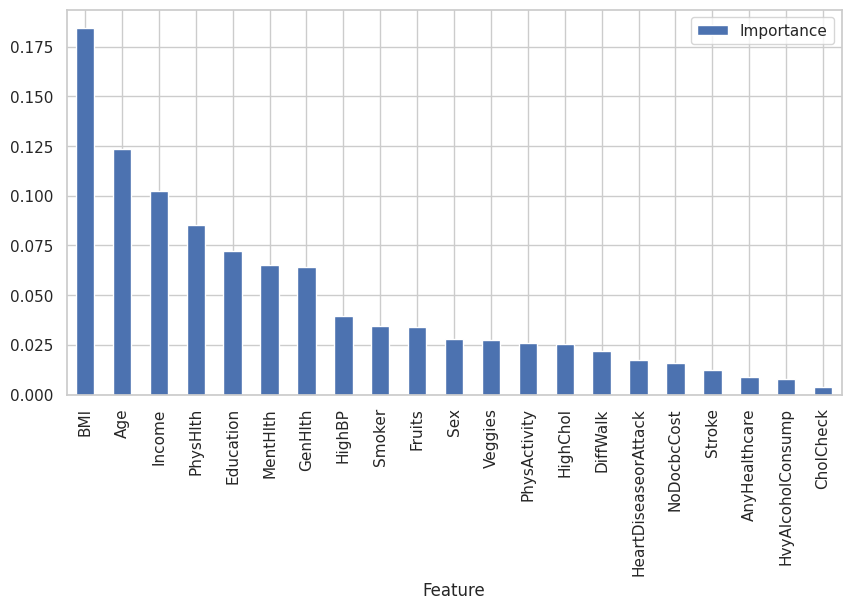

In [156]:
model = RandomForestClassifier()
model.fit(x, y)

importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, score)

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

importance_df.sort_values("Importance", ascending=False).plot.bar(
    x="Feature", y="Importance", figsize=(10,5)
)

In [157]:

# List of alpha values to try
alphas = [0.001, 0.01, 0.1, 1]

best_alpha = None
best_score = -float('inf')

# Hyperparameter tuning using validation set
for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)  # use only training set
    score = model.score(X_val, y_val)  # evaluate on validation set
    if score > best_score:
        best_score = score
        best_alpha = alpha

print("Best alpha:", best_alpha)

# Train final Lasso with best alpha on the training set
final_model = Lasso(alpha=best_alpha)
final_model.fit(X_train, y_train)

# Create a DataFrame with feature weights
weights_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': final_model.coef_
})

weights_df['Magnitude'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='Magnitude', ascending=False)

print(weights_df[['Feature', 'Weight']])

Best alpha: 0.001
                 Feature    Weight
0                 HighBP  0.160669
1               HighChol  0.129010
6   HeartDiseaseorAttack  0.112157
13               GenHlth  0.109524
3                    BMI  0.098206
10     HvyAlcoholConsump -0.091847
2              CholCheck  0.070230
16              DiffWalk  0.069522
18                   Age  0.056391
5                 Stroke  0.049336
17                   Sex  0.038711
20                Income -0.026111
11         AnyHealthcare  0.014147
4                 Smoker -0.010089
7           PhysActivity -0.007717
14              MentHlth -0.006503
19             Education -0.004713
12           NoDocbcCost -0.001957
8                 Fruits -0.000155
9                Veggies -0.000000
15              PhysHlth -0.000000


In [158]:
selected_features = weights_df[weights_df['Magnitude'] > 0.01]['Feature']

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print("Selected Features:", list(selected_features))

Selected Features: ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'GenHlth', 'BMI', 'HvyAlcoholConsump', 'CholCheck', 'DiffWalk', 'Age', 'Stroke', 'Sex', 'Income', 'AnyHealthcare', 'Smoker']


In [159]:
## Random oversampling
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before oversampling:")
print(y_train.value_counts())
print("\nAfter oversampling:")
print(y_train_over.value_counts())

Before oversampling:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After oversampling:
Diabetes_012
0.0    133038
2.0    133038
1.0    133038
Name: count, dtype: int64


In [160]:
# Smote sampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After SMOTE:
Diabetes_012
0.0    133038
2.0    133038
1.0    133038
Name: count, dtype: int64


In [161]:

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before undersampling:")
print(y_train.value_counts())

print("\nAfter undersampling:")
print(y_train_under.value_counts())

Before undersampling:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After undersampling:
Diabetes_012
0.0    3240
1.0    3240
2.0    3240
Name: count, dtype: int64


In [162]:
#### class weights technique for unbalanced data please try it muhnad